In [79]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.numpy as jnp
PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

In [80]:
PKL_titles

['exp_gaussian_3.py_12122024175448.pkl',
 'exp_gaussian_3.py_12122024174801.pkl',
 'exp_gaussian_3.py_12122024175006.pkl']

Text(0.5, 0, 'scale parameter')

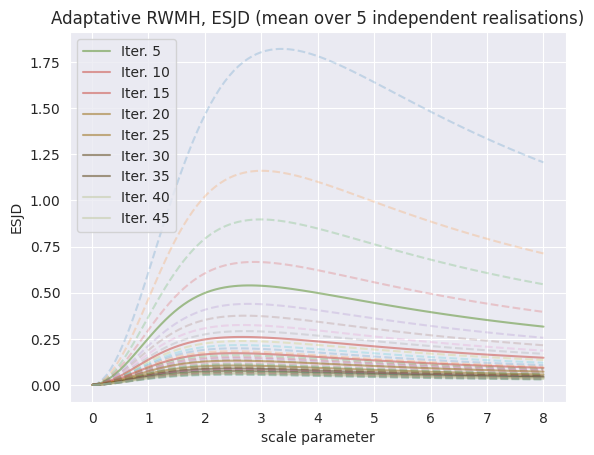

In [85]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
color_set
idx = 2
mpm1 = PKLs[idx]['res'][idx].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    if j % 5 ==0:
        plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:]/mpm1, label=f"Iter. {str(j)}", alpha=0.5, color=color_set[j//10], linestyle="solid")
    else:
        plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:]/mpm1, alpha=0.2, linestyle="--")
plt.legend()
plt.title("Adaptative RWMH, ESJD (mean over 5 independent realisations)")
plt.ylabel("ESJD")
plt.xlabel("scale parameter")

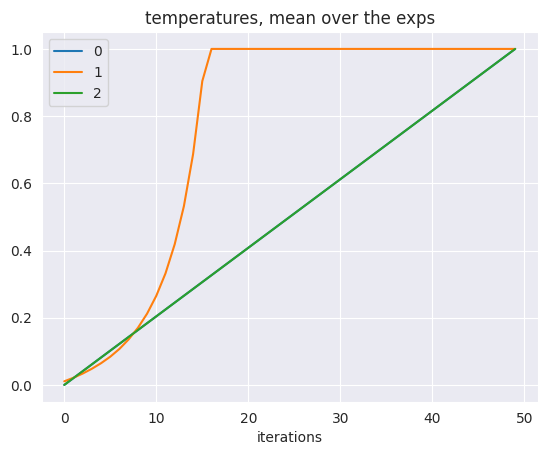

In [86]:
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][6], axis=0), label=f'{idx}')
plt.title('temperatures, mean over the exps')
plt.xlabel('iterations')
plt.legend()

<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_20333/3214708201.py:8: SyntaxWarning: invalid escape sequence '\c'
  """


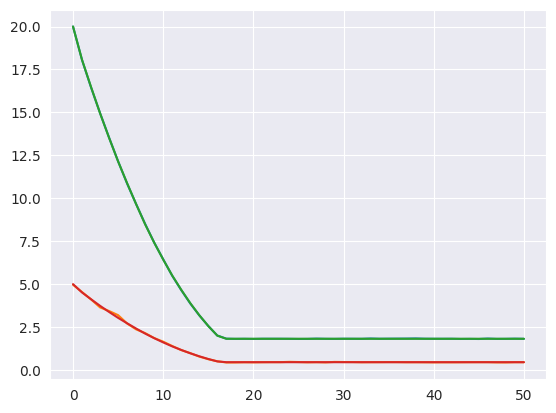

In [87]:
idx = 1
plt.plot([np.mean(PKLs[idx]['res'][0][0,it].reshape(24000)) for it in range(51)])
plt.plot([np.var(PKLs[idx]['res'][0][0,it].reshape(24000)) for it in range(51)])
from functools import partial
import jax
@partial(jax.vmap, in_axes=(0, None, None, None, None))
def get_mean_var(lmbda, mean_prior, mean_ll, cov_prior, cov_ll):
    """
    Compute the mean and var of a Gaussian distribution of the form
        \calN(mean_prior, var_prior) \times \calN(mean_ll, var_ll)^{\lmbda}

    Parameters
    ----------
    lmbda: temperature
    """
    cov = jnp.linalg.inv(jnp.linalg.inv(cov_prior) + jnp.linalg.inv(cov_ll) * lmbda)
    mean = cov @ (jnp.linalg.inv(cov_prior) @ mean_prior + jnp.linalg.inv(cov_ll) @ mean_ll)
    return mean, cov
temperatures = jnp.insert(PKLs[idx]['res'][6][0], 0, 0.)
mean_temp, var_temp = get_mean_var(temperatures, jnp.array([20.]), jnp.array([0.]), jnp.array([[5.]]), jnp.array([[0.5]]))
plt.plot(mean_temp.reshape(-1).T)
plt.plot(var_temp.reshape(-1).T)



In [88]:
PKLs[0]['res'][6][0]

Array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285715, 0.1632653 , 0.18367347,
       0.20408164, 0.2244898 , 0.24489796, 0.26530612, 0.2857143 ,
       0.30612245, 0.3265306 , 0.3469388 , 0.36734694, 0.3877551 ,
       0.40816328, 0.42857143, 0.4489796 , 0.46938777, 0.48979592,
       0.5102041 , 0.53061223, 0.5510204 , 0.5714286 , 0.59183675,
       0.6122449 , 0.63265306, 0.6530612 , 0.67346936, 0.6938776 ,
       0.71428573, 0.7346939 , 0.75510204, 0.7755102 , 0.79591835,
       0.81632656, 0.8367347 , 0.85714287, 0.877551  , 0.8979592 ,
       0.9183673 , 0.93877554, 0.9591837 , 0.97959185, 1.        ],      dtype=float32)

In [89]:
mean_temp

Array([[20.       ],
       [18.059965 ],
       [16.478676 ],
       [14.948463 ],
       [13.518407 ],
       [12.144637 ],
       [10.87766  ],
       [ 9.656034 ],
       [ 8.478216 ],
       [ 7.4169497],
       [ 6.4307065],
       [ 5.5035496],
       [ 4.6713486],
       [ 3.895322 ],
       [ 3.1934536],
       [ 2.561492 ],
       [ 2.001999 ],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.8181818],
       [ 1.81

In [90]:
PKLs[0]['res'][0][0].shape

(51, 4000, 6, 1)

In [91]:
PKLs[0]['res'][6][0]

Array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285715, 0.1632653 , 0.18367347,
       0.20408164, 0.2244898 , 0.24489796, 0.26530612, 0.2857143 ,
       0.30612245, 0.3265306 , 0.3469388 , 0.36734694, 0.3877551 ,
       0.40816328, 0.42857143, 0.4489796 , 0.46938777, 0.48979592,
       0.5102041 , 0.53061223, 0.5510204 , 0.5714286 , 0.59183675,
       0.6122449 , 0.63265306, 0.6530612 , 0.67346936, 0.6938776 ,
       0.71428573, 0.7346939 , 0.75510204, 0.7755102 , 0.79591835,
       0.81632656, 0.8367347 , 0.85714287, 0.877551  , 0.8979592 ,
       0.9183673 , 0.93877554, 0.9591837 , 0.97959185, 1.        ],      dtype=float32)

/tmp/ipykernel_20333/3976088965.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'iteration')

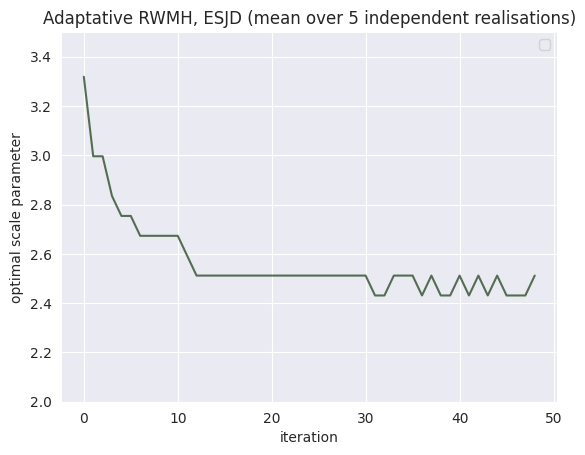

In [96]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
color_set
idx = 2
mpm1 = PKLs[idx]['res'][idx].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
plt.plot([GRID_ESJD[np.argmax(PKLs[idx]['res'][5].mean(axis=0)[j,:])] for j in range(1, PKLs[idx]['res'][5].shape[1])], alpha=0.9, color=color_set[j//10], linestyle="solid")
plt.ylim(2, 3.5)
plt.legend()
plt.title("Adaptative RWMH, ESJD (mean over 5 independent realisations)")
plt.ylabel("optimal scale parameter")
plt.xlabel("iteration")

In [52]:
GRID_ESJD[np.argmax(PKLs[idx]['res'][5].mean(axis=0)[j,:])]

Array(2.4565303, dtype=float32)

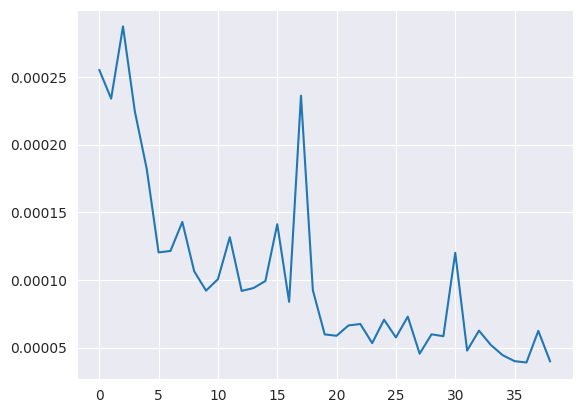

In [33]:
plt.plot(PKLs[0]['res'][5][..., -1][...,10:].mean(axis=0).T/16000)

In [26]:
PKLs[1]['res'][5].shape

(5, 49, 1)

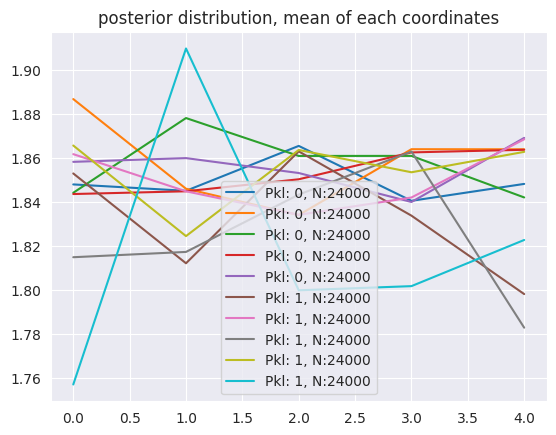

In [47]:
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][0][:,-1], axis=[1, 2]).T, label=f'Pkl: {idx}, N:{np.prod(PKLs[idx]['res'][0][-1].shape[1:3])}')
plt.title('posterior distribution, mean of each coordinates')
plt.legend()

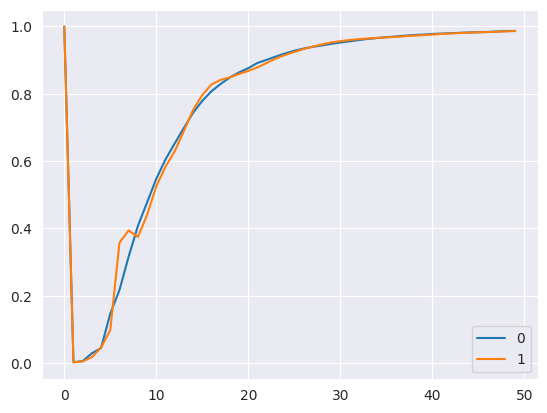

In [48]:
for idx in range(n):
    weights = np.exp(PKLs[idx]['res'][1][:,:,].reshape((*PKLs[idx]['res'][1].shape[:2], -1)))
    num_particles = weights.shape[-1]
    plt.plot(np.mean(1/np.sum(np.square(weights), axis=-1).T/num_particles, axis=-1), label=idx)
plt.legend()

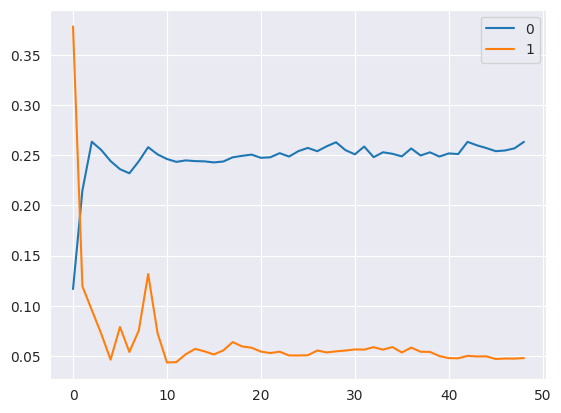

In [49]:
for idx in range(n):
    plt.plot(PKLs[idx]['res'][3][0].mean(axis=[1, 2]), label=idx)
plt.legend()

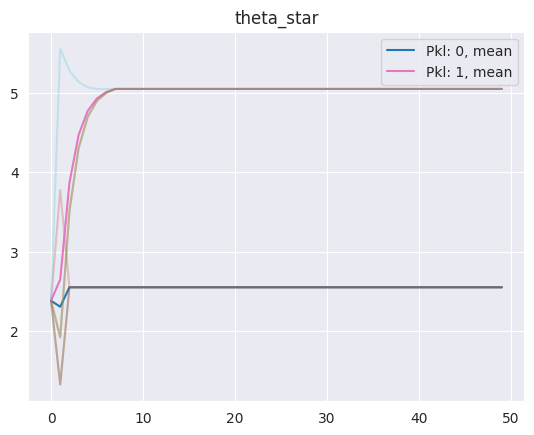

In [50]:
for idx in range(n):
    plt.plot(PKLs[idx]['res'][2][...,0].mean(axis=0), label=f"Pkl: {idx}, mean")
    plt.plot(PKLs[idx]['res'][2][...,0].T, alpha=0.2)
plt.title("theta_star")
plt.legend()

In [61]:
PKLs[0]['res'][2][...,0]

Array([[2.38 , 3.775, 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 ],
       [2.38 , 1.325, 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 ],
       [2.38 , 1.325, 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 ,
        2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.55 , 2.5

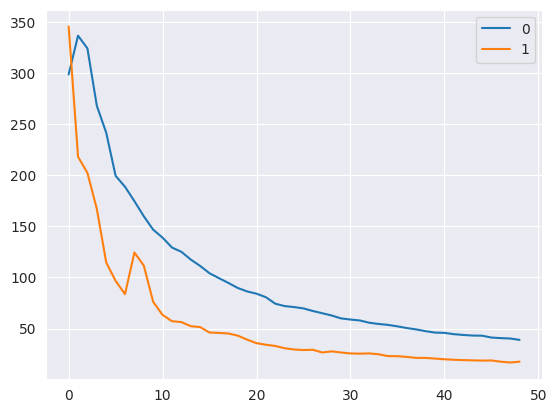

In [51]:
for idx in range(n):
    plt.plot(np.sum(np.square(np.diff(PKLs[idx]['res'][0], axis=-2, n=5)), axis=-1).mean(axis=-1).mean(axis=-1).mean(axis=0)[1:], label=idx)
plt.legend()

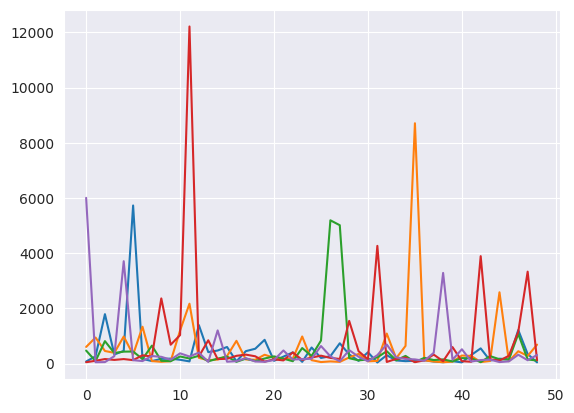

In [58]:
import jax
import jax.numpy as jnp
idx=0
is_weights = jnp.exp(PKLs[idx]['res'][4])
is_weights = is_weights.reshape(is_weights.shape[:2] + (-1,))
is_weights_shape = is_weights.shape
is_weights = is_weights.reshape(-1, is_weights.shape[-1])
var_over_mean_sq = jax.vmap(lambda s: jnp.var(s)/jnp.mean(s)**2, in_axes=(0))(is_weights)
var_over_mean_sq = var_over_mean_sq.reshape(is_weights_shape[:2])
plt.plot(var_over_mean_sq.T)

In [17]:
t = PKLs[0]['res'][0][:,-1].reshape(5, 6000, 2)

In [20]:
t.std(axis=1)

Array([[0.8010515 , 0.9449333 ],
       [0.89503694, 0.92496437],
       [0.91653776, 0.9336953 ],
       [0.82355976, 0.9749086 ],
       [0.929272  , 0.88048685]], dtype=float32)